## Overview
The purpose of this document is to try and identify the physical cause of the 200kHz peak in the impedance spectrum of a IS curve.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import DRT as drt
from pySIMsalabim.experiments.impedance import *
import pandas as pd

In [15]:
# Load in command pairs data
project_directory_path = "/home/josh-edmundson/Documents/Projects/Using DRT to Investigate the 200kHz Impedance Peak"
data_directory_path = os.path.join(project_directory_path, "Random Samples Generated by Sander/Impedance_felec_files-20260218T091323Z-1-001/Impedance_felec_files")
cmd_pairs_filename = 'cmd_pars_run_pars_listed_UUID.txt'

cmd_pairs = pd.read_csv(os.path.join(data_directory_path, cmd_pairs_filename), sep=r"\s+")
cmd_pairs.head()

,idx,l1.L,l1.eps_r,l1.N_c,l1.N_D,l1.mu_n,l1.E_t_int,l1.N_t_int,l1.C_n_int,l1.C_p_int,...,l3.eps_r,l3.N_c,l3.N_A,l3.mu_p,l3.E_t_int,l3.N_t_int,l3.C_n_int,l3.C_p_int,W_L,W_R
0,2,2.438900e-08,7.7530,1.922900e+26,1.306600e+22,5.030400e-06,5.2028,3.892000e+12,1.806700e-14,3.165800e-15,...,3.4510,3.129500e+25,1.360200e+23,1.230700e-06,4.5456,4.705200e+11,3.875100e-15,3.002900e-15,4.1938,5.3319
1,6,3.171800e-08,8.3265,4.602900e+26,1.447400e+23,1.880500e-06,4.4084,8.445700e+12,1.814200e-15,4.521900e-15,...,9.2151,7.034700e+25,7.126000e+22,2.353100e-07,4.1908,1.997400e+12,2.335500e-14,1.364200e-15,4.1034,5.2728
2,1,4.357900e-08,8.6308,1.845200e+26,4.341600e+21,3.239100e-06,4.1053,2.139500e+12,4.523200e-15,4.623700e-14,...,6.7220,1.784900e+25,4.171000e+21,1.622000e-06,5.1445,1.543300e+11,2.290200e-14,8.866700e-15,4.2060,5.1835
3,3,3.199000e-08,9.0470,2.159000e+25,2.330400e+20,2.111200e-06,5.3399,3.177500e+12,4.070900e-14,2.840800e-14,...,8.9977,1.568700e+26,6.785600e+20,2.600100e-07,4.4326,8.535300e+11,3.954500e-15,1.817200e-15,4.2381,5.2958
4,4,2.107500e-08,10.5680,1.759700e+26,2.516800e+23,2.290200e-07,4.9263,6.287500e+12,1.503800e-14,1.344400e-15,...,9.6924,2.075900e+26,1.414200e+22,3.223900e-07,5.1878,1.113100e+12,4.074500e-14,4.797200e-15,4.0821,5.3286


In [ ]:
unique_sample_ids = cmd_pairs['idx'].unique()

In [ ]:
# Generate and save 10 random samples
# random_sample_ids = np.random.choice(unique_sample_ids, size=(10), replace=False)
# random_sample_identifier = "".join(map(str, random_sample_ids))

# random_samples_save_path = os.path.join(project_directory_path, "10 Random Samples", random_sample_identifier)
# pd.DataFrame({"Id": random_sample_ids}).to_csv(random_samples_save_path)

In [39]:
# Read random samples, store id and sim file data in a dictionary, and add that dictionary to a sample list
random_samples_file_names = "25151361491211288782133"
random_sample_ids = pd.read_csv(os.path.join(project_directory_path, "10 Random Samples", random_samples_file_names))['Id']
file_types = ["tj_Voc_L", "freqZ_Voc_L", "tj_0V_L", "freqZ_0V_L"]

random_samples = []

for id in random_sample_ids:
    sample = {"sample_id" : id}

    for file_type in file_types:
        file_name = f"{file_type}_{id}.dat"
        file_path = os.path.join(data_directory_path, file_name)
        file_data = pd.read_csv(file_path, sep=r'\s+')
        sample[file_type] = file_data
    
    random_samples.append(sample)

## Applying DRT
Now that I've successfully loaded in the data for each of 10 random samples, I want to apply DRT processing. This will require me to:
1. Find an appropriate startTime for the DRT fit. From past experience, this looks to be round 1E-7s as the system has enough time to relax from the inital perturbation while preserving the peak at 100kHz (~1E-6 s)
2. Apply DRT to these cleaned signals and store the DRT results, likely in 10_random_samples 

133
5e-09


Text(0.5, 1.0, 'Current curves ')

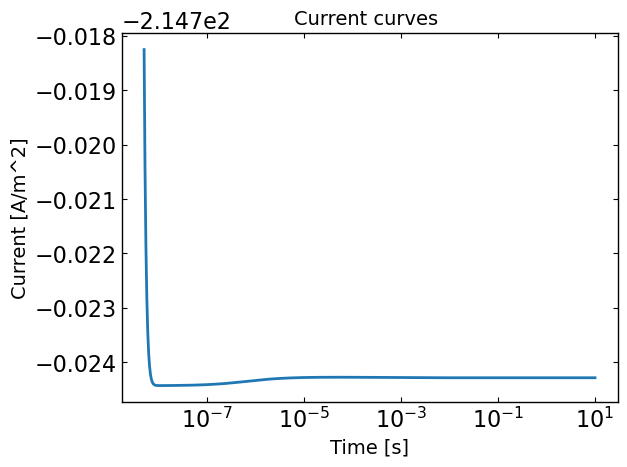

In [ ]:
# Check for an appropriate time slice for Voc
# The tVG frequency range was from 1E-1Hz - 1E8Hz, 20 steps, with Delta V = 5mV
f_max = 1E8
f_min = 1E-1


# Lowest desired lifetime
tau_min = 1/f_max 
tau_max = 1/f_min

sample_index = 9

sample = random_samples[sample_index]
print(sample["sample_id"])
time = sample["tj_0V_L"]["t"].values
current = sample["tj_0V_L"]["Jext"].values

# Set time based on the maximum observable time window
start_time = 1/(2*f_max)
print(start_time)

# Clean up the current
filter = np.where(time > start_time)
current = current[filter]
time = time[filter]

plt.plot(time, current)
plt.xscale("log")
plt.ylabel("Current [A/m^2]")
plt.xlabel("Time [s]")
plt.title("Current curves ")

In [198]:
drt_fits = drt.checkerboard_fit(time, current)

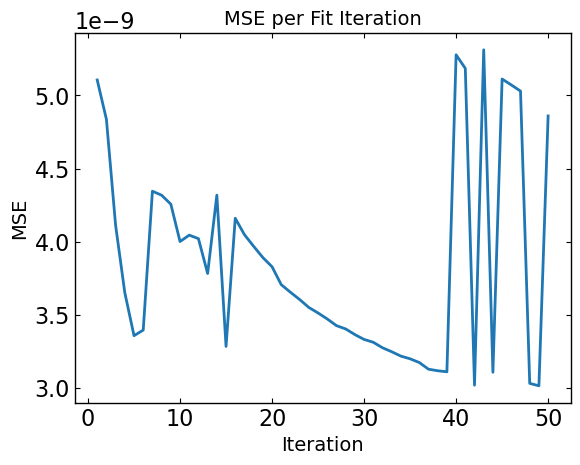

In [199]:
drt.plot_MSE(drt_fits)

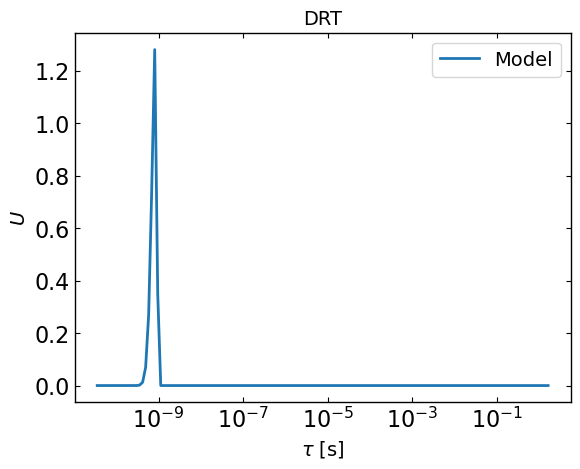

In [206]:
drt_fits[0].plot_U()

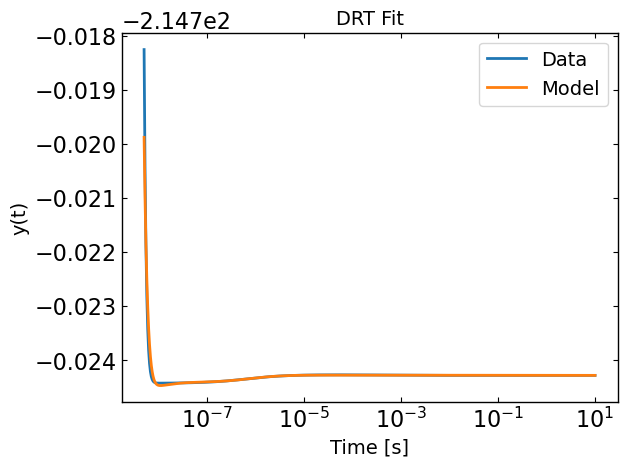

In [205]:
drt_fits[0].plot_y_model(time, current)

133


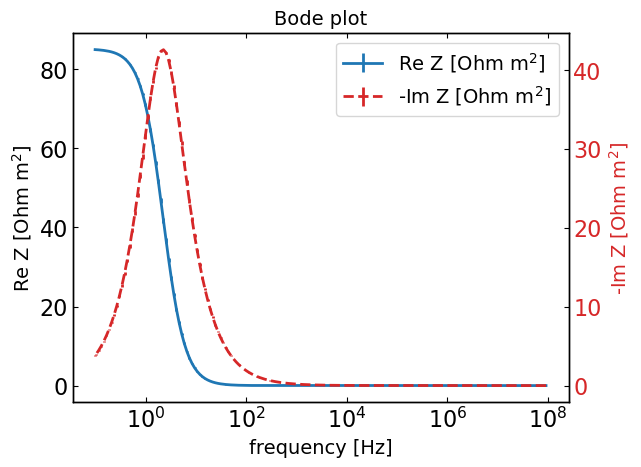

In [202]:
file_path = f"freqZ_0V_L_{sample["sample_id"]}.dat"
print(sample["sample_id"])
Bode_plot(data_directory_path, file_path)

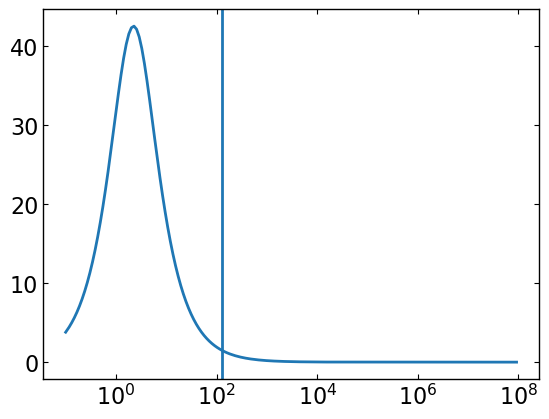

In [203]:
# Find the peak frequency here 
from scipy.signal import find_peaks
find_peaks(-1*sample['freqZ_0V_L']["ImZ"].values, )
plt.plot(sample['freqZ_0V_L']['freq'].values, -1*sample['freqZ_0V_L']['ImZ'].values)
plt.axvline(130)
plt.xscale('log')

In [204]:
(-1*sample['freqZ_0V_L']["ImZ"]).argmax()

np.int64(147)